---
execute:
  skip: true
authors:
- name: David V. Smith
doi: 10.5281/zenodo.19627256
github: https://github.com/neurodesk/neurodeskedu/blob/main/books/examples/functional_imaging/Demo_fmriprep_FEAT.ipynb
edit_url: https://github.com/neurodesk/neurodeskedu/edit/main/books/examples/functional_imaging/Demo_fmriprep_FEAT.ipynb
downloads:
- url: /edu/_sources/examples/functional_imaging/Demo_fmriprep_FEAT.ipynb
  title: Download source notebook
  filename: Demo_fmriprep_FEAT.ipynb
  static: false
---
# Scripted First-Level Analyses in FSL using fMRIPrep data

:::{admonition} Reviewed
:class: nd-review-badge nd-review-badge--reviewed

[review issue](<https://github.com/neurodesk/neurodeskedu-reviews/issues/51>) · [@marlapinkert](<https://github.com/marlapinkert>)
:::

:::{dropdown} Run this notebook
:class: nd-launch

- [Run in Australia](<https://play.neurodesk.cloud.edu.au/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/functional_imaging/Demo_fmriprep_FEAT.ipynb&branch=main>)
- [Run in Europe](<https://play-europe.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/functional_imaging/Demo_fmriprep_FEAT.ipynb&branch=main>)
- [Run in America](<https://play-america.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/functional_imaging/Demo_fmriprep_FEAT.ipynb&branch=main>)
- [Run in Global Server 1](<https://play-europe.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/functional_imaging/Demo_fmriprep_FEAT.ipynb&branch=main>)
- [Run in Global Server 2](<https://edu.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/functional_imaging/Demo_fmriprep_FEAT.ipynb&branch=main>)
:::


This notebook walks through a simple, novice-friendly workflow in **Neurodesk EDU**:

1. install one OpenNeuro dataset and get one subject  
2. run **fMRIPrep** for one task/run from that subject and extract FEAT-ready confounds  
3. convert BIDS `events.tsv` files to FSL 3-column EV files  
4. render and run a first-level FEAT model from a trust-game FEAT template  
5. make a first pass at viewing the result in **NiiVue**


**Author**: <div style="margin-top: 10px;">
    <a href="https://orcid.org/0000-0001-5754-9633" target="_blank" style="color: #0066cc;">
        <i class="fab fa-orcid"></i> David V. Smith
    </a>
</div>

**Date**: April 2, 2026  

**License**: <div style="margin-top: 10px;">
    <a href="https://opensource.org/licenses/MIT" target="_blank" style="color: #0066cc;">
        <i class="fas fa-balance-scale"></i> MIT License
    </a>
</div>

**Provenance:** This notebook adapts course materials and selected logic from the Fareri trust-game workflow code, but rewrites the steps so they can be followed directly in notebook cells. Full workflow repository: [tubric/fareri-2022-neuroimage](https://github.com/tubric/fareri-2022-neuroimage).

**Acknowledgments:** This notebook was generated with assistance from ChatGPT-5 across several iterations and then revised by the instructor. The instructor reviewed the final content and takes responsibility for it.



### Citation and Resources

#### Study-specific references
- **Fareri et al. (2022)**: Fareri, D. S., Hackett, K., Tepfer, L. J., Kelly, V., Henninger, N., Reeck, C., Giovannetti, T., & Smith, D. V. (2022). *Age-related differences in ventral striatal and default mode network function during reciprocated trust.* **NeuroImage, 256**, 119267. https://doi.org/10.1016/j.neuroimage.2022.119267
- **Smith et al. (2024)**: Smith, D. V., Ludwig, R. M., Dennison, J. B., Reeck, C., & Fareri, D. S. (2024). *An fMRI Dataset on Social Reward Processing and Decision Making in Younger and Older Adults.* **Scientific Data, 11**(1), 158. https://doi.org/10.1038/s41597-024-02931-y

#### Full workflow repository
- **Fareri trust-game workflow repo**: [https://github.com/tubric/fareri-2022-neuroimage](https://github.com/tubric/fareri-2022-neuroimage)

#### Tools included in this workflow
- **fMRIPrep**: Esteban, O., Markiewicz, C. J., Blair, R. W., *et al.* (2019). fMRIPrep: a robust preprocessing pipeline for functional MRI. *Nature Methods, 16*, 111–116.
- **FSL / FEAT**: Jenkinson, M., Beckmann, C. F., Behrens, T. E. J., Woolrich, M. W., & Smith, S. M. (2012). FSL. *NeuroImage, 62*, 782–790.
- **DataLad**: Halchenko, Y. O., Meyer, K., Poldrack, B., *et al.* (2021). DataLad: distributed system for joint management of code, data, and their relationship. *Journal of Open Source Software, 6*, 3262.
- **bidsutils / BIDSto3col.sh**: Tom Nichols and contributors. `bids-standard/bidsutils`.
- **NiiVue / ipyniivue** for interactive image viewing in Jupyter.

#### Dataset
- **OpenNeuro ds003745** (trust game dataset used in class materials and labs)

#### Educational resources
- Course labs on Neurodesk, fMRIPrep, FEAT, and 3-column event files.


## Table of content
[1. Load software tools and import python libraries](#id-1-load-software-tools-and-import-python-libraries)  
[2. Data preparation](#id-2-data-preparation)  
[3. Run fMRIPrep for one selected run](#id-3-run-fmriprep-for-one-selected-run)  
[4. Make a FEAT confounds file](#id-4-make-a-feat-confounds-file)  
[5. Convert events.tsv to 3-column files](#id-5-convert-events-tsv-to-3-column-files)  
[6. Render the FEAT template](#id-6-render-the-feat-template)  
[7. Run first-level FEAT](#id-7-run-first-level-feat)  
[8. Fix FEAT registration for fMRIPrep-preprocessed data](#id-8-fix-feat-registration-for-fmriprep-preprocessed-data)  
[9. Results](#id-9-results)  
[10. Dependencies in Jupyter/Python](#10.-Dependencies-in-Jupyter/Python)


## 1. Load software tools and import python libraries

In [1]:
import module
await module.load('fmriprep/25.2.5')
await module.load('fsl/6.0.7.22')
await module.list()

['fmriprep/25.2.5', 'fsl/6.0.7.22']

In [2]:
%%capture
!pip install pandas

In [3]:
from pathlib import Path
import os
import glob
import pandas as pd
from IPython.display import display, Markdown, Image

base_dir = Path.home() / "trust_example"
print(base_dir)

/home/jovyan/trust_example


## 2. Data preparation

We will keep everything for this example in one folder directly under the home directory:

`~/trust_example`

That makes the paths easy to read, and it also makes it easier to rerun or delete the whole example later if you want a clean start.

Inside that folder, we will make a few subdirectories:

- `templates/` for the FEAT template  
- `bids/` for the OpenNeuro dataset  
- `derivatives/` for fMRIPrep output, confounds, EV files, and FEAT output  
- `scratch/` for temporary working files  
- `bidsutils/` for Tom Nichols' `BIDSto3col.sh`


In [4]:
%%bash
set -e

EXAMPLE_DIR="$HOME/trust_example"

mkdir -p "$EXAMPLE_DIR"
cd "$EXAMPLE_DIR"

# Keep the example organized in one project folder.
mkdir -p templates bids derivatives scratch

# Copy the one FEAT template we need.
curl -L \
  https://raw.githubusercontent.com/tubric/fareri-2022-neuroimage/main/templates/L1_task-trust_model-01_type-act.fsf \
  -o templates/L1_task-trust_model-01_type-act.fsf

# Install bidsutils separately so we can use BIDSto3col.sh.
if [ ! -d bidsutils ]; then
  git clone --depth 1 https://github.com/bids-standard/bidsutils.git
fi

# Install the OpenNeuro dataset skeleton and get the full subject recursively.
cd bids
if [ ! -d ds003745 ]; then
  datalad install https://github.com/OpenNeuroDatasets/ds003745.git
fi

cd ds003745
datalad get -r sub-104


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
      

                           Dload  Upload   T

otal   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:-

-     0

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

...

104_task-trust_run-03_bold.nii.gz (file) [from s3-PUBLIC...]
get(ok): sub-104/func/sub-104_task-trus

t_run-04_bold.nii.gz (file) [from s3-PUBLIC...]
get(ok): sub-104/func/sub-104_task-trust_run-05_bold

.nii.gz (file) [from s3-PUBLIC...]
get(ok): sub-104/func/sub-104_task-ultimatum_run-01_bold.nii.gz (

file) [from s3-PUBLIC...]
get(ok): sub-104/func/sub-104_task-ultimatum_run-02_bold.nii.gz (file) [fr

om s3-PUBLIC...]
get(ok): sub-104 (directory)
action summary:
  get (ok: 15)


In [5]:
!tree -L 3 ~/trust_example/templates
!tree -L 3 ~/trust_example/bids/ds003745/sub-104

/home/jovyan/trust_example/templates
└── L1_task-trust_model-01_type-act.fsf

1 directory, 1 file


/home/jovyan/trust_example/bids/ds003745/sub-104
├── anat
│   ├── sub-104_T1w.json
│   ├── sub-104_T1w.nii.gz -> ../../.git/annex/objects/wM/31/MD5E-s8381149--5fd51ee8f8b1d0fa00490acab7054f44.nii.gz/MD5E-s8381149--5fd51ee8f8b1d0fa00490acab7054f44.nii.gz
│   ├── sub-104_T2w.json
│   └── sub-104_T2w.nii.gz -> ../../.git/annex/objects/Z3/xJ/MD5E-s9405965--d643b78dc1b963c582be22a5e67576c5.nii.gz/MD5E-s9405965--d643b78dc1b963c582be22a5e67576c5.nii.gz
├── fmap
│   ├── sub-104_magnitude1.json
│   ├── sub-104_magnitude1.nii.gz -> ../../.git/annex/objects/5p/kK/MD5E-s227307--ff542908f56f6acec5e8ef22a84ec4b2.nii.gz/MD5E-s227307--ff542908f56f6acec5e8ef22a84ec4b2.nii.gz
│   ├── sub-104_magnitude2.json
│   ├── sub-104_magnitude2.nii.gz -> ../../.git/annex/objects/fz/8J/MD5E-s225256--6926b13a836ec3487bb68649bf0f36cb.nii.gz/MD5E-s225256--6926b13a836ec3487bb68649bf0f36cb.nii.gz
│   ├── sub-104_phasediff.json
│   └── sub-104_phasediff.nii.gz -> ../../.git/annex/objects/Qw/1v/MD5E-s315320--78621dbba52c9

The example below uses:

- **subject**: `104`
- **task**: `trust`
- **run**: `01`

That keeps the notebook manageable, but the same logic can be repeated for the other runs.

For teaching purposes, one run is a nice compromise: the model is still realistic, but the files and paths stay simple enough to follow line by line.


## 3. Run fMRIPrep for one selected run

The next cell runs fMRIPrep on one participant for the trust task and run 01. It writes the outputs under `~/trust_example/derivatives/fmriprep`.

The task is selected with `--task-id trust`. The `--bids-filter-file` narrows fMRIPrep's BOLD-file query to `run-01`, so the example processes only the run used later by FEAT.

A few practical notes:

- the FreeSurfer license file should exist at `~/.license`
- this command will likely take **a couple of hours** to run
- if you are wondering whether it is still running, go back to the **Terminal** and type `top`
- the `antsRegistration` step is especially slow, so long stretches of apparent inactivity are normal
- we use `MNI152NLin6Asym:res-2` so the preprocessed BOLD file lands on a 2 mm MNI grid that is easy to use alongside standard FSL templates and atlases

One important detail: the `res-2` part controls the **output grid** of the resampled BOLD files. It does **not** change the resolution used for the underlying nonlinear normalization.


In [6]:
# Request a freesurfer license and store it in your homedirectory. 
# This is just an example - please replace with your license id:
!echo "Steffen.Bollmann@cai.uq.edu.au" > ~/.license
!echo "21029" >> ~/.license
!echo "*Cqyn12sqTCxo" >> ~/.license
!echo "FSxgcvGkNR59Y" >> ~/.license

In [7]:
!ls -l ~/.license

-rw-rw-r-- 1 jovyan jovyan 65 Jul 21 07:13 /home/jovyan/.license


In [8]:
%%bash
set -e

EXAMPLE_DIR="$HOME/trust_example"

sub=104
BIDS_DIR="$EXAMPLE_DIR/bids/ds003745"
OUT_DIR="$EXAMPLE_DIR/derivatives/fmriprep"
WORK_DIR="$EXAMPLE_DIR/scratch/fmriprep_work"
BIDS_FILTER="$EXAMPLE_DIR/scratch/bids_filter_task-trust_run-01.json"
FS_LIC="$HOME/.license"

mkdir -p "$OUT_DIR" "$WORK_DIR"

cat > "$BIDS_FILTER" <<'JSON'
{
  "bold": {
    "datatype": "func",
    "suffix": "bold",
    "run": "01"
  }
}
JSON

mkdir -p "$HOME/freesurfer-subjects-dir"
export SUBJECTS_DIR="$HOME/freesurfer-subjects-dir"

# This command will likely take a couple of hours to finish.
# If you want to confirm that it is still running, go back to the
# Terminal and type: top
# The antsRegistration process is especially slow and can run for
# a long time without printing much new output.

fmriprep \
  "$BIDS_DIR" \
  "$OUT_DIR" \
  participant \
  --participant-label "$sub" \
  --task-id trust \
  --bids-filter-file "$BIDS_FILTER" \
  --stop-on-first-crash \
  --fs-license-file "$FS_LIC" \
  --fs-subjects-dir "$SUBJECTS_DIR" \
  --fs-no-reconall \
  --output-spaces MNI152NLin6Asym:res-2 \
  -w "$WORK_DIR"

bids-validator@1.14.10


(node:2381) Warning: Closing directory handle on garbage collection
(Use `node --trace-warnings ...`

 to show where the warning was created)


This dataset appears to be BIDS compatible.
        Summary:           

        Available Tasks:        Available Modalities: 
       

...

vesDataSink>


260721-07:49:04,832 nipype.workflow INFO:
	 [Node] Finished "ds_bold", elapsed time 32.246415s.


260721-07:49:08,461 nipype.workflow IMPORTANT:
	 fMRIPrep finished successfully!


260721-07:49:08,466 nipype.workflow IMPORTANT:
	 Works derived from this fMRIPrep execution should i

nclude the boilerplate text found in <OUTPUT_PATH>/logs/CITATION.md.


When fMRIPrep finishes, the files we care about most for FEAT are:

- the HTML report
- the preprocessed BOLD file for the run we want
- the confounds table for that run

Because we wrote the outputs into `~/trust_example/derivatives/fmriprep`, the next steps can keep using the same paths throughout the notebook.

If the HTML report does not open correctly inside Neurodesktop, open it through **JupyterLab** instead. It is worth checking the report before moving on, because bad preprocessing or bad alignment will usually be easier to catch here than later in the FEAT output.


In [9]:
!find ~/trust_example/derivatives/fmriprep -name "sub-104.html"
!find ~/trust_example/derivatives/fmriprep -name "*run-01*desc-preproc_bold.nii.gz"
!find ~/trust_example/derivatives/fmriprep -name "*run-01*desc-confounds_timeseries.tsv"

/home/jovyan/trust_example/derivatives/fmriprep/sub-104.html


/home/jovyan/trust_example/derivatives/fmriprep/sub-104/func/sub-104_task-trust_run-01_space-MNI152NLin6Asym_res-2_desc-preproc_bold.nii.gz


/home/jovyan/trust_example/derivatives/fmriprep/sub-104/func/sub-104_task-trust_run-01_desc-confounds_timeseries.tsv


## 4. Make a FEAT confounds file

Here we take the fMRIPrep confounds table for one run and save a FEAT-ready text file.

We keep:
- cosine regressors
- non-steady-state regressors
- 6 motion parameters
- the first 6 aCompCor components
- framewise displacement, if it exists

FEAT wants a plain text file **without a header**, so we write the output that way.

This is a good example of why notebook workflows can be useful for teaching: you can see exactly which nuisance regressors are being kept, rather than hiding that logic inside a separate script.


In [10]:
confounds_tsv = base_dir / "derivatives" / "fmriprep" / "sub-104" / "func" / "sub-104_task-trust_run-01_desc-confounds_timeseries.tsv"
confounds = pd.read_csv(confounds_tsv, sep="	")

# Keep a simple but still realistic set of nuisance regressors.
cosine_cols = [c for c in confounds.columns if c.startswith("cosine")]
nss_cols = [c for c in confounds.columns if c.startswith("non_steady_state")]
motion_cols = ["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z"]
acompcor_cols = [c for c in confounds.columns if c.startswith("a_comp_cor_")][:6]
fd_cols = ["framewise_displacement"] if "framewise_displacement" in confounds.columns else []

keep_cols = cosine_cols + nss_cols + motion_cols + acompcor_cols + fd_cols
feat_confounds = confounds[keep_cols].fillna(0)

out_dir = base_dir / "derivatives" / "fsl" / "confounds" / "sub-104"
out_dir.mkdir(parents=True, exist_ok=True)

out_file = out_dir / "sub-104_task-trust_run-01_desc-fslConfounds.tsv"
feat_confounds.to_csv(out_file, sep="	", header=False, index=False)

print(out_file)
print(feat_confounds.shape)
feat_confounds.head()


/home/jovyan/trust_example/derivatives/fsl/confounds/sub-104/sub-104_task-trust_run-01_desc-fslConfounds.tsv
(217, 19)


,cosine00,cosine01,cosine02,cosine03,cosine04,non_steady_state_outlier00,trans_x,trans_y,trans_z,rot_x,rot_y,rot_z,a_comp_cor_00,a_comp_cor_01,a_comp_cor_02,a_comp_cor_03,a_comp_cor_04,a_comp_cor_05,framewise_displacement
0,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,-0.028677,-0.050250,0.041419,-0.001136,-0.000077,-3.280445e-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.096223,0.096215,0.096202,0.096184,0.096161,0.0,-0.020840,-0.050390,0.077573,-0.000667,-0.000360,-1.197739e-07,0.092616,-0.026204,0.101412,-0.034399,0.042093,-0.077511,0.098113
2,0.096202,0.096133,0.096019,0.095859,0.095653,0.0,-0.016589,-0.015174,0.059022,-0.000540,-0.000058,-2.060158e-04,-0.018382,0.116795,0.089136,-0.041624,0.022263,0.072593,0.089766
3,0.096161,0.095971,0.095653,0.095209,0.094639,0.0,-0.009081,-0.045662,0.038655,-0.000667,0.000078,2.599182e-08,-0.086435,0.021827,-0.071150,0.036173,-0.004025,-0.012221,0.081813
4,0.096100,0.095727,0.095105,0.094237,0.093125,0.0,-0.012794,0.007354,0.047157,-0.000667,-0.000073,-2.435978e-08,-0.049187,0.018794,-0.086241,0.033125,0.006822,-0.001962,0.072783


## 5. Convert events.tsv to 3-column files

This step uses `BIDSto3col.sh` from **bidsutils** and keeps the logic to one run.

`BIDSto3col.sh` reads the BIDS events file and writes one 3-column text file per event type.  
Each output file has three columns:

1. onset  
2. duration  
3. weight

Those output files are exactly the kind of timing files FEAT expects for custom EVs, so this is one of the main bridges between a BIDS dataset and an FSL first-level model.


In [11]:
%%bash
set -e

EXAMPLE_DIR="$HOME/trust_example"

sub=104
run=01
events_tsv="$EXAMPLE_DIR/bids/ds003745/sub-${sub}/func/sub-${sub}_task-trust_run-${run}_events.tsv"
out_base="$EXAMPLE_DIR/derivatives/fsl/EVfiles/sub-${sub}/trust/run-${run}"

mkdir -p "$(dirname "$out_base")"

# This creates one 3-column file per event type found in the BIDS events file.
bash "$EXAMPLE_DIR/bidsutils/BIDSto3col/BIDSto3col.sh" "$events_tsv" "$out_base"

Creating '/home/jovyan/trust_example/derivatives/fsl/EVfiles/sub-104/trust/run-01_choice_computer.tx

t'

Creating '/home/jovyan/trust_example/derivatives/fsl/EVfiles/sub-104/trust/run-01_choice_friend.txt'

Creating '/home/jovyan/trust_example/derivatives/fsl/EVfiles/sub-104/trust/run-01_choice_stranger.tx

t'

...

ip.txt'

Creating '/home/jovyan/trust_example/derivatives/fsl/EVfiles/sub-104/trust/run-01_outcome_stranger_d

efect.txt'

Creating '/home/jovyan/trust_example/derivatives/fsl/EVfiles/sub-104/trust/run-01_outcome_stranger_r

ecip.txt'

In [12]:
!ls ~/trust_example/derivatives/fsl/EVfiles/sub-104/trust
!head -n 5 ~/trust_example/derivatives/fsl/EVfiles/sub-104/trust/run-01_choice_computer.txt

run-01_choice_computer.txt	    run-01_outcome_computer_recip.txt
run-01_choice_friend.txt	    run-01_outcome_friend_defect.txt
run-01_choice_stranger.txt	    run-01_outcome_friend_recip.txt
run-01_missed_trial.txt		    run-01_outcome_stranger_defect.txt
run-01_outcome_computer_defect.txt  run-01_outcome_stranger_recip.txt


4.03279	1.860030	1.0
35.3721	1.830190	1.0
90.4619	2.570010	1.0
178.15	2.770810	1.0
212.465	2.416930	1.0


## 6. Render the FEAT template

The template file already contains the FEAT model structure.  
What changes from subject to subject and run to run are the **paths** and a few settings.

This is a useful pattern for reproducible work: keep the design mostly fixed, and then fill in the parts that should vary across runs.

### Placeholders we replace
- `OUTPUT` → where the `.feat` directory should be written  
- `DATA` → the preprocessed BOLD file from fMRIPrep  
- `EVDIR` → the prefix used by the EV timing files  
- `MISSED_TRIAL` → path to the optional missed-trial EV file  
- `EV_SHAPE` → `3` if the missed-trial file exists, otherwise `10` for an empty EV  
- `SMOOTH` → smoothing kernel in mm  
- `CONFOUNDEVS` → the confounds file we just created


In [13]:
template_text = (base_dir / "templates" / "L1_task-trust_model-01_type-act.fsf").read_text()

for token in ["OUTPUT", "DATA", "EVDIR", "MISSED_TRIAL", "EV_SHAPE", "SMOOTH", "CONFOUNDEVS"]:
    print(f"--- lines containing {token} ---")
    for line in template_text.splitlines():
        if token in line:
            print(line)
    print()

--- lines containing OUTPUT ---
set fmri(outputdir) "OUTPUT"

--- lines containing DATA ---
set feat_files(1) "DATA"

--- lines containing EVDIR ---
set fmri(custom1) "EVDIR_choice_computer.txt"
set fmri(custom2) "EVDIR_choice_friend.txt"
set fmri(custom3) "EVDIR_choice_stranger.txt"
set fmri(custom4) "EVDIR_outcome_computer_defect.txt"
set fmri(custom5) "EVDIR_outcome_computer_recip.txt"
set fmri(custom6) "EVDIR_outcome_friend_defect.txt"
set fmri(custom7) "EVDIR_outcome_friend_recip.txt"
set fmri(custom8) "EVDIR_outcome_stranger_defect.txt"
set fmri(custom9) "EVDIR_outcome_stranger_recip.txt"

--- lines containing MISSED_TRIAL ---
set fmri(custom10) "MISSED_TRIAL"

--- lines containing EV_SHAPE ---
set fmri(shape10) EV_SHAPE

--- lines containing SMOOTH ---
set fmri(smooth) SMOOTH

--- lines containing CONFOUNDEVS ---
set confoundev_files(1) "CONFOUNDEVS"



The next cell renders a new `.fsf` file. Each variable is written out explicitly so you can see what is being inserted.

Even if you do not remember every line of FEAT syntax, the important lesson is that the `.fsf` file is just text. That means you can inspect it, edit it, and generate it systematically.


In [14]:
%%bash
set -e

EXAMPLE_DIR="$HOME/trust_example"

TASK=trust
SMOOTH=6
sub=104
run=01

OUTPUT="$EXAMPLE_DIR/derivatives/fsl/sub-${sub}/L1_task-${TASK}_model-01_type-act_run-${run}_sm-${SMOOTH}"
DATA="$EXAMPLE_DIR/derivatives/fmriprep/sub-${sub}/func/sub-${sub}_task-${TASK}_run-${run}_space-MNI152NLin6Asym_res-2_desc-preproc_bold.nii.gz"
CONFOUNDEVS="$EXAMPLE_DIR/derivatives/fsl/confounds/sub-${sub}/sub-${sub}_task-${TASK}_run-${run}_desc-fslConfounds.tsv"
EVDIR="$EXAMPLE_DIR/derivatives/fsl/EVfiles/sub-${sub}/${TASK}/run-${run}"
MISSED_TRIAL="${EVDIR}_missed_trial.txt"

if [ -e "$MISSED_TRIAL" ]; then
  EV_SHAPE=3
else
  EV_SHAPE=10
fi

mkdir -p "$(dirname "$OUTPUT")"

sed \
  -e "s@OUTPUT@${OUTPUT}@g" \
  -e "s@DATA@${DATA}@g" \
  -e "s@EVDIR@${EVDIR}@g" \
  -e "s@MISSED_TRIAL@${MISSED_TRIAL}@g" \
  -e "s@EV_SHAPE@${EV_SHAPE}@g" \
  -e "s@SMOOTH@${SMOOTH}@g" \
  -e "s@CONFOUNDEVS@${CONFOUNDEVS}@g" \
  "$EXAMPLE_DIR/templates/L1_task-trust_model-01_type-act.fsf" \
  > "$EXAMPLE_DIR/derivatives/fsl/sub-${sub}/L1_sub-${sub}_task-${TASK}_model-01_run-${run}_act.fsf"


In [15]:
rendered_fsf = base_dir / "derivatives" / "fsl" / "sub-104" / "L1_sub-104_task-trust_model-01_run-01_act.fsf"
print(rendered_fsf)
print()
print(rendered_fsf.read_text()[:4000])

/home/jovyan/trust_example/derivatives/fsl/sub-104/L1_sub-104_task-trust_model-01_run-01_act.fsf


# FEAT version number
set fmri(version) 6.00

# Are we in MELODIC?
set fmri(inmelodic) 0

# Analysis level
# 1 : First-level analysis
# 2 : Higher-level analysis
set fmri(level) 1

# Which stages to run
# 0 : No first-level analysis (registration and/or group stats only)
# 7 : Full first-level analysis
# 1 : Pre-processing
# 2 : Statistics
set fmri(analysis) 7

# Use relative filenames
set fmri(relative_yn) 0

# Balloon help
set fmri(help_yn) 1

# Run Featwatcher
set fmri(featwatcher_yn) 0

# Cleanup first-level standard-space images
set fmri(sscleanup_yn) 0

# Output directory
set fmri(outputdir) "/home/jovyan/trust_example/derivatives/fsl/sub-104/L1_task-trust_model-01_type-act_run-01_sm-6"

# TR(s)
set fmri(tr) 2.020000

# Total volumes
set fmri(npts) 217

# Delete volumes
set fmri(ndelete) 0

# Perfusion tag/control order
set fmri(tagfirst) 1

# Number of first-level analyses
set fmri

## 7. Run first-level FEAT

This command runs FEAT on the rendered design file.

At this point, the main conceptual pieces are in place: preprocessed data, confounds, EV timing files, and a rendered design file. FEAT now uses those pieces to estimate the first-level GLM.


In [16]:
%%bash
set -e

# Run FEAT on the rendered first-level design file.
feat "$HOME/trust_example/derivatives/fsl/sub-104/L1_sub-104_task-trust_model-01_run-01_act.fsf"

To view the FEAT progress and final report, point your web browser at /home/jovyan/trust_example/der

ivatives/fsl/sub-104/L1_task-trust_model-01_type-act_run-01_sm-6.feat/report_log.html


## 8. Fix FEAT registration for fMRIPrep-preprocessed data

Because the functional image already came out of fMRIPrep in standard space, FEAT's usual registration outputs are not the right ones to trust here.  
The next cell follows the same post-FEAT registration fix used in the original `L1stats.sh` script.

This is based on the [NeuroStars post](https://neurostars.org/t/performing-full-glm-analysis-with-fsl-on-the-bold-images-preprocessed-by-fmriprep-without-re-registering-the-data-to-the-mni-space/784/3) referenced in that script.  

In plain language, this step tells FEAT to treat the input as already being in standard space, so the registration files inside the `.feat` directory do not point to misleading transforms.


In [17]:
%%bash
set -e

OUTPUT="$HOME/trust_example/derivatives/fsl/sub-104/L1_task-trust_model-01_type-act_run-01_sm-6"

# fix registration as per NeuroStars post:
# https://neurostars.org/t/performing-full-glm-analysis-with-fsl-on-the-bold-images-preprocessed-by-fmriprep-without-re-registering-the-data-to-the-mni-space/784/3
mkdir -p ${OUTPUT}.feat/reg
ln -sf $FSLDIR/etc/flirtsch/ident.mat ${OUTPUT}.feat/reg/example_func2standard.mat
ln -sf $FSLDIR/etc/flirtsch/ident.mat ${OUTPUT}.feat/reg/standard2example_func.mat
ln -sf ${OUTPUT}.feat/mean_func.nii.gz ${OUTPUT}.feat/reg/standard.nii.gz

## 9. Results

The FEAT output directory should now contain the standard report, design matrix, and statistical maps.

A few files worth checking first are:

- `report.html`
- `design.png`
- `thresh_zstat1.nii.gz`
- `thresh_zstat2.nii.gz`
- `thresh_zstat10.nii.gz`

This is also a good point to slow down and inspect the outputs before interpreting anything. Make sure the design looks sensible, the report opens, and the expected thresholded maps actually exist.


In [18]:
feat_dir = base_dir / "derivatives" / "fsl" / "sub-104" / "L1_task-trust_model-01_type-act_run-01_sm-6.feat"

for rel in [
    "report.html",
    "design.png",
    "thresh_zstat1.nii.gz",
    "thresh_zstat2.nii.gz",
    "thresh_zstat10.nii.gz",
]:
    p = feat_dir / rel
    print(f"{p}: {p.exists()}")

/home/jovyan/trust_example/derivatives/fsl/sub-104/L1_task-trust_model-01_type-act_run-01_sm-6.feat/report.html: True
/home/jovyan/trust_example/derivatives/fsl/sub-104/L1_task-trust_model-01_type-act_run-01_sm-6.feat/design.png: True
/home/jovyan/trust_example/derivatives/fsl/sub-104/L1_task-trust_model-01_type-act_run-01_sm-6.feat/thresh_zstat1.nii.gz: True
/home/jovyan/trust_example/derivatives/fsl/sub-104/L1_task-trust_model-01_type-act_run-01_sm-6.feat/thresh_zstat2.nii.gz: True
/home/jovyan/trust_example/derivatives/fsl/sub-104/L1_task-trust_model-01_type-act_run-01_sm-6.feat/thresh_zstat10.nii.gz: True


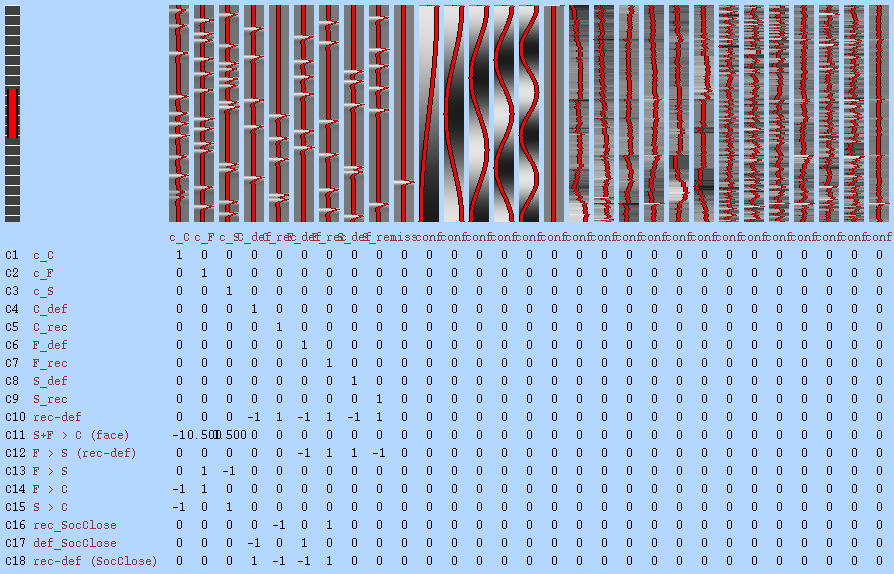

In [19]:
design_png = feat_dir / "design.png"
if design_png.exists():
    display(Image(filename=str(design_png)))
else:
    print("Run FEAT first, then come back to this cell.")

### Optional: try a quick NiiVue visualization

This cell overlays a thresholded FEAT result on the example functional image from the same run.

Here we use `thresh_zstat10.nii.gz`, which corresponds to **reciprocate > defect**. In this task, that contrast is roughly reward-related, so even in a single run you may see activation in the **ventral striatum** and nearby reward-sensitive regions.

A few learning notes:

- `example_func.nii.gz` gives you a background image in the same space as the FEAT results, but it's a little blurry
- `MNI152_T1_2mm_brain.nii.gz` is a T1 background in MNI space and should be better for visualization. 
- `thresh_zstat10.nii.gz` is already thresholded, so the overlay is easier to interpret
- if your notebook shows nothing, first confirm that the `.feat` directory exists and that `thresh_zstat10.nii.gz` is really there


In [20]:
from pathlib import Path
from IPython.display import display
from ipyniivue import NiiVue
import nibabel as nib
import numpy as np

# FEAT background and contrast map from the same run
# bg = str(feat_dir / "example_func.nii.gz")
bg = "/cvmfs/neurodesk.ardc.edu.au/containers/fsl_6.0.7.16_20250131/fsl_6.0.7.16_20250131.simg/opt/fsl-6.0.7.16/data/standard/MNI152_T1_2mm_brain.nii.gz"
zmap = str(feat_dir / "thresh_zstat10.nii.gz")  # reciprocate > defect

print("Background exists:", Path(bg).exists(), bg)
print("Contrast exists:", Path(zmap).exists(), zmap)

if Path(bg).exists() and Path(zmap).exists():
    # Load the EPI background and choose a sensible display window
    epi = nib.load(bg).get_fdata()
    epi_nonzero = epi[epi > 0]

    lo = float(np.percentile(epi_nonzero, 2))
    hi = float(np.percentile(epi_nonzero, 98))

    nv = NiiVue()
    nv.load_volumes([
        {
            "path": bg,
            "name": "example_func",
            "colormap": "gray",
            "opacity": 1.0,
            "cal_min": lo,
            "cal_max": hi
        },
        {
            "path": zmap,
            "name": "reciprocate > defect",
            "colormap": "red",
            "opacity": 0.45
        }
    ])
    display(nv)
else:
    print("Run FEAT first, then come back to this cell.")

Background exists: True /cvmfs/neurodesk.ardc.edu.au/containers/fsl_6.0.7.16_20250131/fsl_6.0.7.16_20250131.simg/opt/fsl-6.0.7.16/data/standard/MNI152_T1_2mm_brain.nii.gz
Contrast exists: True /home/jovyan/trust_example/derivatives/fsl/sub-104/L1_task-trust_model-01_type-act_run-01_sm-6.feat/thresh_zstat10.nii.gz


#### Dependencies in Jupyter/Python
- Using the package [watermark](https://github.com/rasbt/watermark) to document system environment and software versions used in this notebook, alongside the Neurodesktop version extracted from the `JUPYTER_IMAGE` or `NEURODESKTOP_VERSION` environment variables.

In [21]:
import os

%load_ext watermark

%watermark
%watermark --iversions

neurodesktop_version = (
    os.environ.get('JUPYTER_IMAGE', '').split(':')[-1] or
    os.environ.get('NEURODESKTOP_VERSION', 'unknown')
)

print(f"Neurodesktop version: {neurodesktop_version}")

Last updated: 2026-07-21T08:06:50.027303+00:00

Python implementation: CPython
Python version       : 3.13.14
IPython version      : 9.12.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 6.8.0-111-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit

IPython  : 9.12.0
ipyniivue: 2.4.4
nibabel  : 5.4.2
numpy    : 2.5.1
pandas   : 2.3.3

Neurodesktop version: 2026-07-11
